In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import h5py
import sys
sys.path.append('../')
import analysis_utils as utils

from scipy.signal import welch
from scipy.signal.windows import hann
from scipy.fft import fft, fftfreq, rfft, irfft, rfftfreq
from scipy.special import voigt_profile
from scipy.optimize import curve_fit

yale_colors = ['#00356b', '#286dc0', '#63aaff', '#4a4a4a']
utils.load_plotting_setting()

In [2]:
import importlib
importlib.reload(utils)

<module 'analysis_utils' from '/Users/yuhan/work/nanospheres/dm_nanospheres/analysis_notebooks/../analysis_utils.py'>

In [3]:
rho = 2000 # kg/m^3
m = rho * (83e-9)**3 * 4 * np.pi / 3

c = 299792458  # m/s
kb = 1.38e-23
hbar = 1.054571817e-34
omega0 = 2 * np.pi * 50500
# omega0 = 2 * np.pi * 50430.2978515625

SI2ev = (1 / 1.6e-19) * c

zpf = np.sqrt(hbar / (2 * m * omega0))
pzpf = np.sqrt(hbar * m * omega0 / 2)

In [4]:
def get_c_d_integrals(na):
    thetamax = np.arcsin(na)
    C = 2 * ( 8 / 15 - (np.cos(thetamax)**(3/2) ) / 3 - (np.cos(thetamax)**(5/2) ) / 5 )
    D = 2 * ( 12 / 35 - (np.cos(thetamax)**(5/2) ) / 5 - (np.cos(thetamax)**(7/2) ) / 7 )
    
    return C, D

def calc_geometric_factor(na):
    """Calculate the geometric factor A using Eq. (A3), (E2a) and (E2b) of https://arxiv.org/pdf/1907.12838.pdf"""
    C, D = get_c_d_integrals(na)
    return D / C

In [5]:
c_mv = 6.711030676159362e-08

#### Estimate scattered power and noise based on the measured reheating rate

In [6]:
gamma_reheating = 35833 * 2 * np.pi * 2 / 2
gamma_reheating_gas = 2201 * 2 * np.pi * 2 / 2
gamma_damping_reheating = 0.46 * 2 * np.pi

S_ff_ba = 4 * pzpf**2 * gamma_reheating         # N^2 / Hz
S_zz_imp = (zpf**2) / (4 * gamma_reheating)     # m^2 / Hz

# Estimate the one-sided thermal force spectral density from the
# measured gas heating rate
small_gamma_th_kb_T = gamma_reheating_gas * (hbar * omega0)
sf_th = 4 * small_gamma_th_kb_T * m
print(f'Measured gas force spectrum: {sf_th} N^2/Hz')

Measured gas force spectrum: 8.86666278161278e-42 N^2/Hz


In [7]:
kb = 1.38e-23

p_mbar = 1.7e-8
p_pascal = p_mbar * 100

R = 8.3144  # J/(mol K)
m_gas = 2.016e-3 * 0.6 + 18.01528e-3 * 0.4  # kg / mol
T = 292  # K
vbar = np.sqrt(8 * R * T / (np.pi * m_gas))  # m/s

r_sphere_0 = 83e-9
m_sphere_0 = 2000 * 4/3 * np.pi * r_sphere_0**3

gamma_th = (64/3) * r_sphere_0**2 * p_pascal / (m_sphere_0 * vbar)
sf_th_th = 4 * kb * T * gamma_th * m_sphere_0
print(f'Theory gas force spectrum: {sf_th_th} N^2/Hz')

Theory gas force spectrum: 4.698446077247262e-42 N^2/Hz


In [8]:
na = 0.77
lambd = 1064e-9
k = 2 * np.pi / lambd

A = calc_geometric_factor(na=na)
p_sca = S_ff_ba / ((A**2 + 2/5) * hbar * k / c)

print(f'Scattered laser power = {p_sca * 1e6:.2f} uW')
print(f'Backaction noise (one-sided): {S_ff_ba * 2:.3e} N^2/Hz')
print(f'Imprecision noise floor (one-sided): {S_zz_imp * 2:.3e} m^2/Hz')

Scattered laser power = 31.83 uW
Backaction noise (one-sided): 1.444e-40 N^2/Hz
Imprecision noise floor (one-sided): 7.704e-29 m^2/Hz


In [9]:
na = 0.77
lambd = 1064e-9
k = 2 * np.pi / lambd

A = calc_geometric_factor(na=na)
_p_sca = 40.999e-6  # W
_s_ff_ba = ((A**2 + 2/5) * hbar * k / c) * _p_sca
_gamma_ba = _s_ff_ba / (2 * m * omega0 * hbar)

print(f'Scattered laser power = {_p_sca * 1e6:.2f} uW')
print(f'Backaction noise (double-sided): {_s_ff_ba:.3e} N^2/Hz')
print(f'Backaction heating rate: {_gamma_ba/1000/(2*np.pi):.3f} kHz')

Scattered laser power = 41.00 uW
Backaction noise (double-sided): 9.297e-41 N^2/Hz
Backaction heating rate: 46.158 kHz


#### Plot the measured spectrum and estimate info collection efficiency

In [10]:
# frerq, vpp = 163000, 4
# f = h5py.File(f'/Users/yuhan/work/nanospheres/data/pulse_calibration/sphere_20250406/20250412_electric_calibration_2e-8mbar/20250412_d_m8e_{int(freq/1000)}khz_{vpp}vpp_trapping_0.hdf5')
f = h5py.File('/Users/yuhan/work/nanospheres/data/pulse_calibration/sphere_20250406/20250412_electric_calibration_2e-8mbar/20250412_d_m8e_nodrive_3.hdf5', 'r')

dtt = f['data'].attrs['delta_t']
fs = int(np.ceil(1 / dtt))   # Sampling rate at Hz
zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv'] / 1e3  # Signal in V
zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)

f.close()

In [11]:
def get_sz_measured(zz, n_spectrum, n_chunk):
    size_per_chunk = int(zz.size / n_chunk)
    hann_window = hann(size_per_chunk)

    # Correction factor for Hann windowing
    # See https://dsp.stackexchange.com/questions/93512/effects-of-hanning-window-on-power
    hann_psd_scaling = np.sum(hann_window**2)

    ff, s_zzs, s_ffs = None, [], []
    for i in range(n_spectrum):
        zz_calc = zz[i*size_per_chunk : (i+1)*size_per_chunk]
        zz_windowed = hann_window * zz_calc

        s_zz = np.abs(rfft(zz_windowed))**2 / (fs * hann_psd_scaling)
        s_zzs.append(s_zz)

        ff = rfftfreq(size_per_chunk, dtt)
        f0 = ff[ff > 30000][np.argmax(s_zz[ff > 30000])]
        omega0 = f0 * 2 * np.pi
        # gamma0 = 0.34 * 2 * np.pi
        gamma0 = (ff[1] - ff[0]) * 2 * np.pi

        omega = ff * 2 * np.pi
        chi_omega = 1 / (m * (omega0**2 - omega**2 - 1j * gamma0 * omega))
        # s_ffs.append(s_zz / (np.abs(chi_omega)**2))

    s_zs = 2 * np.array(s_zzs)
    # s_fs = 2 * np.array(s_ffs)

    sz_measured = np.mean(s_zs, axis=0) * c_mv**2
    
    return ff, sz_measured

In [12]:
ff, sz_measured = get_sz_measured(zz, n_spectrum=10, n_chunk=400)
# sf_measured = np.mean(s_fs, axis=0) * c_mv**2

idx_max = np.argmax(sz_measured[ff > 30000])
omega0 = 2 * np.pi * ff[ff > 30000][idx_max]
gamma0 = (ff[1] - ff[0]) * 2 * np.pi 

omega = ff * 2 * np.pi
chi_omega = 1 / (m * (omega0**2 - omega**2 - 1j * gamma0 * omega))
sf_measured = sz_measured / (np.abs(chi_omega) ** 2)

idx_int = np.logical_and(ff>0, ff<200000)
# idx_int = np.logical_and(ff>40000, ff<60000)

# There is a factor of 4 when integrating over the single-sided spectral density!
dp_kev = np.sqrt( 1/( np.trapz(4/sf_measured[idx_int], x=ff[idx_int]*2*np.pi) /(2*np.pi) ) ) * SI2ev / 1000

print(f'Predicted impulse sensitivity: {dp_kev:.3f} keV/c')

Predicted impulse sensitivity: 61.123 keV/c


In [13]:
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

def gaussian_convolved_lineshape(omega, A, omega0, sigma, gamma):
    xx_gauss = np.arange(-400*2*np.pi, 400*2*np.pi, 1)
    gauss_kernel = gauss(xx_gauss, A=1, mu=0, sigma=sigma)
    gauss_kernel /= np.sum(gauss_kernel)

    xx = np.arange(20000*2*np.pi, 120000*2*np.pi, 1)
    actual_lineshape = A / ((xx**2 - omega0**2)**2 + gamma**2 * xx**2)
    
    convolved_lineshape = np.convolve(gauss_kernel, actual_lineshape, 'same')
    return np.interp(omega, xx, convolved_lineshape)

def voigt(xx, A, x0, sigma, gamma):
    return A * voigt_profile(xx-x0, sigma, gamma)

def fit_sigma_voigt(ff, sz, gamma=None):
    fit_idx_voigt = np.logical_and(ff > 45000, ff < 55000)

    popt, pcov = curve_fit(lambda xx, A, f0, sigma, gamma: voigt(xx, A, f0, sigma, gamma), ff[fit_idx_voigt]*2*np.pi, sz[fit_idx_voigt], 
                           p0=[3e-18, 50500*2*np.pi, 50*2*np.pi, 1*2*np.pi], sigma=sz[fit_idx_voigt])
    
    # If don't want to fit for gamma
    # popt, pcov = curve_fit(lambda xx, A, f0, sigma: voigt(xx, A, f0, sigma, gamma), ff[fit_idx_voigt]*2*np.pi, sz[fit_idx_voigt], 
    #                        p0=[1e-18, 50000*2*np.pi, 43*2*np.pi], sigma=sz[fit_idx_voigt])
    
    return popt

def fit_gaussian_convolved_lineshape(ff, sz):
    fit_idx = np.logical_and(ff > 45000, ff < 70000)

    popt, pcov = curve_fit(lambda xx, A, omega0, sigma, gamma: gaussian_convolved_lineshape(xx, A, omega0, sigma, gamma), ff[fit_idx]*2*np.pi, sz[fit_idx], 
                           p0=[1e-18, 50000*2*np.pi, 400*2*np.pi, 0.43*2*np.pi], sigma=sz[fit_idx])
    return popt

A, omega0, sigma, gamma_voigt = fit_sigma_voigt(ff, sz_measured)
print(A, omega0/(2*np.pi), sigma, gamma_voigt)

# A, f0, sigma, gamma = fit_gaussian_convolved_lineshape(ff, sz_measured)
# print(A, f0/(2*np.pi), sigma, gamma)

5.9945763009176e-18 50497.60923931324 375.67345323413576 6.644451758689284


In [14]:
gamma = gamma_voigt * 2

# Use the sigma and gamma extracted from voigt fit
# to calculate the broadend lineshape
# gamma/2 is the corresponding Lorentzian linewidth if the true oscillator
# had damping gamma
convolved_lineshape = gaussian_convolved_lineshape(ff*2*np.pi, 1, omega0, sigma, gamma)
chi_2_convolved = (1 / (m**2)) * convolved_lineshape

# convolved_lineshape = voigt(ff*2*np.pi, 1, omega0, sigma, gamma)
# chi_2_convolved = (1 / (4 * m**2)) * convolved_lineshape * (np.pi / gamma)

sf_measured_convolved = sz_measured / (chi_2_convolved)

idx_int = np.logical_and(ff>30000, ff<100000)
dp_kev = np.sqrt( 1/( np.trapz(4/sf_measured_convolved[idx_int], x=ff[idx_int]*2*np.pi) /(2*np.pi) ) ) * SI2ev / 1000

print(f'Predicted impulse sensitivity: {dp_kev:.3f} keV/c')

Predicted impulse sensitivity: 64.825 keV/c


In [15]:
T = 295
td = 1.12e-3
d = 3.1e-3
epsilon0 = 8.85e-12

epsilon_real = 1.788325**2
loss_tangent = 1e-3
epsilon = epsilon_real * (1 + 1j*loss_tangent)

rho = 2.65e-8

q = 10 * 1.6e-19

s_ee = 0.5 * ( (3 * kb * T * td * np.imag(-1 * epsilon0 / epsilon)/ (8 * np.pi * epsilon0 * omega0 * d**4)) + kb * T * rho / (4 * np.pi * d**3))
s_ff = s_ee * q**2

In [21]:
idx_int = np.logical_and(ff > 30000, ff < 80000)
print(np.trapz(sz_measured[idx_int], omega[idx_int]) / (2 * np.pi) * m * omega0**2 / kb)
print(np.trapz(sz_measured[idx_int], omega[idx_int]) / (2 * np.pi) * m * omega0**2 / (hbar * omega0))

0.03509104914161939
14472.667770130092


Estimated measurement rate: 1.904 \pm 0.286 kHz
Estimated information collection efficiency: 0.0524
Estimated information collection efficiency (no thermal noise): 0.0531


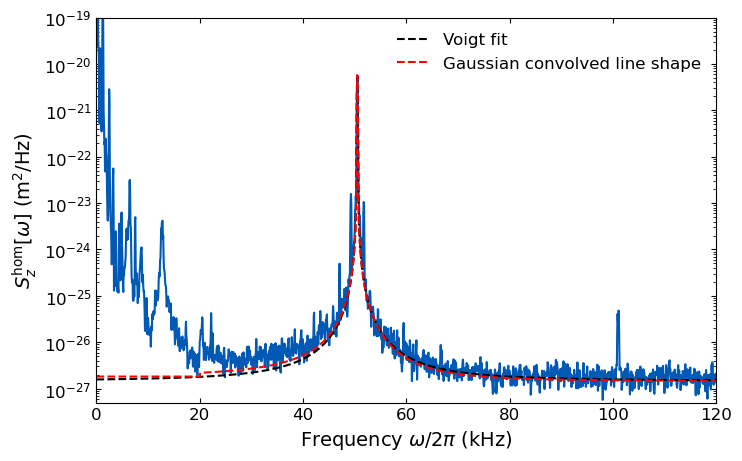

In [45]:
omega = ff * 2 * np.pi
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Take the imprecision noise to be averaged value
# from 500 to 750 kHz
fit_idx = np.logical_and(ff > 500000, ff < 750000)
sz_noisefloor = np.mean(sz_measured[fit_idx])

ax.plot(ff/1000, sz_measured, '-', color='#005AB5')
# ax.plot(ff/1000, A / ((omega**2 - omega0**2)**2 + gamma**2 * omega**2))

ax.plot(ff/1000, voigt(omega, A, omega0, sigma, gamma_voigt) + sz_noisefloor, 'k--', label='Voigt fit')

convolved_lineshape = gaussian_convolved_lineshape(ff*2*np.pi, 1, omega0, sigma, gamma_voigt*2)
scaling_factor = (sz_measured[ff>30000][np.argmax(sz_measured[ff > 30000])] - sz_noisefloor) / convolved_lineshape[ff>30000][np.argmax(sz_measured[ff > 30000])]
ax.plot(ff/1000,  scaling_factor * convolved_lineshape + sz_noisefloor, 'r--', label='Gaussian convolved line shape')

ax.legend(frameon=False)
ax.set_yscale('log')
ax.set_xlim(0, 120)
ax.set_ylim(5e-28, 1e-19)

ax.set_xlabel(r'Frequency $\omega/2 \pi$ (kHz)')
ax.set_ylabel(r'$S^{\mathrm{hom}}_z$[$\omega$] (m$^2$/Hz)')

eta = S_zz_imp * 2 / sz_noisefloor
# eta = S_zz_imp * 2 / x_fit[4]
gamma_meas_khz = zpf**2 / (4 * sz_noisefloor / 2) / (1000 * 2*np.pi)

print(fr'Estimated measurement rate: {gamma_meas_khz:.3f} \pm {gamma_meas_khz * 0.15:.3f} kHz')
print(f'Estimated information collection efficiency: {gamma_meas_khz / (gamma_reheating/(2*np.pi*1000) + 0.511):.4f}')
print(f'Estimated information collection efficiency (no thermal noise): {eta:.4f}')


#### Theory curves

In [23]:
def gaussian_convolved_chi(omega, m, omega0, sigma, gamma, chi_inv=False):
    xx_gauss = np.arange(-400*2*np.pi, 400*2*np.pi, 1)
    gauss_kernel = gauss(xx_gauss, A=1, mu=0, sigma=sigma)
    gauss_kernel /= np.sum(gauss_kernel)

    xx = np.arange(20000*2*np.pi, 120000*2*np.pi, 1)
    # Calculate theh convolved 1/chi instead of chi
    if not chi_inv:
        actual_chi = (1/m) / ((xx**2 - omega0**2) - 1j * gamma * xx)
    else:
        actual_chi = m * ((xx**2 - omega0**2) - 1j * gamma * xx)

    real_chi = np.real(actual_chi)
    imag_chi = np.imag(actual_chi)

    convolved_real_chi = np.convolve(gauss_kernel, real_chi, 'same')
    convolved_imag_chi = np.convolve(gauss_kernel, imag_chi, 'same')

    return np.interp(omega, xx, convolved_real_chi), np.interp(omega, xx, convolved_imag_chi)


In [38]:
# Always integrate over double-sided spectra to avoid confusion...
# also numerical integration over one-sided spectra gives incorrect values sometimes
# look into more in the future
omega_theory = np.linspace(-2*200e3*np.pi, 2*200e3*np.pi, 2000000)

# chi_ba = (1 / m) / (omega0**2 - omega_theory**2 - gamma * omega_theory * 1j) # Complex susceptibility
convolved_lineshape_theory = gaussian_convolved_lineshape(omega_theory, 1, omega0, sigma, gamma)
chi_2_convolved_theory = (1 / (m**2)) * convolved_lineshape_theory

convolved_real_chi, convolved_imag_chi = gaussian_convolved_chi(omega_theory, m, omega0, sigma, gamma)
S_zz_zpf = hbar * convolved_imag_chi
S_ff_zpf = hbar * m * gamma * omega0

# S_zz_zpf = 0.5 * zpf**2 * gamma * convolved_lineshape_theory * 1e10

# ZPF force noise (single sided)
# S_f_zpf = 2 * hbar * m * gamma * omega0

# SQL curves
# S_z_sql = 2 * hbar * (np.abs(chi_ba))
# S_f_sql = 2 * hbar / (np.abs(chi_ba))

In [36]:
Sf_total = np.full_like(omega_theory, sz_noisefloor/chi_2_convolved_theory) + np.full_like(omega_theory, 2*S_ff_ba + sf_th) + np.full_like(omega_theory, 2*S_ff_zpf)

idx_int = np.logical_and((omega_theory/(2*np.pi))>0, (omega_theory/(2*np.pi))<200000)
dp_kev_theory = np.sqrt( 1/( np.trapz(4/Sf_total[idx_int], x=omega_theory[idx_int] /(2*np.pi) ) )) * SI2ev / 1000
print(f'Predicted theory impulse sensitivity: {dp_kev_theory:.3f} keV/c')

idx_int = np.logical_and((omega_theory/(2*np.pi))>0, (omega_theory/(2*np.pi))<200000)

chi_omega_theory = 1 / (m * (omega0**2 - omega_theory**2 - 1j * gamma * omega_theory))
Sf_total_ideal = np.full_like(omega_theory, (2*S_zz_imp) / (np.abs(chi_omega_theory)**2) + np.full_like(omega_theory, 2*S_ff_ba))

dp_kev_theory_ideal = np.sqrt( 1/( np.trapz(4 / Sf_total_ideal[idx_int], x=omega_theory[idx_int]) /(2*np.pi) )) * SI2ev / 1000
print(fr'Predicted theory impulse sensitivity ($\eta$ = 1): {dp_kev_theory_ideal:.3f} keV/c')

Predicted theory impulse sensitivity: 54.788 keV/c
Predicted theory impulse sensitivity ($\eta$ = 1): 34.970 keV/c


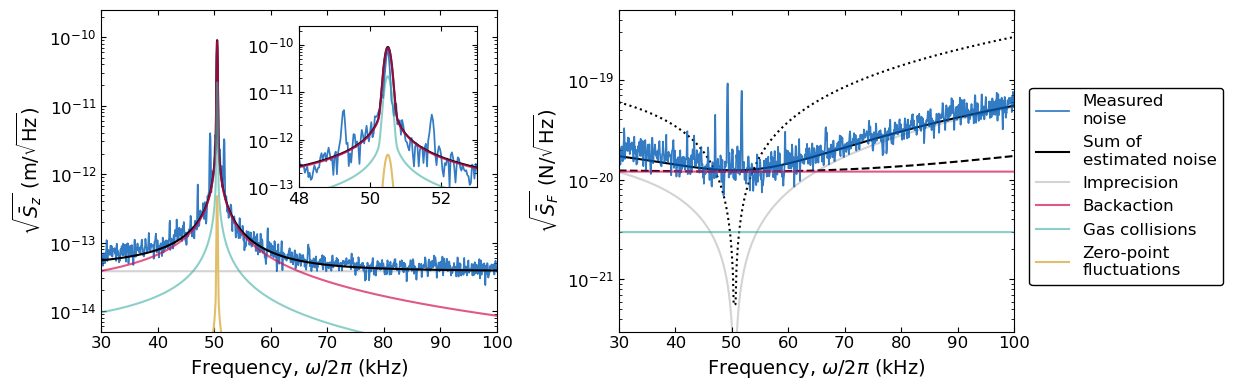

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))

axes[0].plot(ff/1000, np.sqrt(sz_measured), '-', color='#005AB5', linewidth=1.25, alpha=0.8, label='Measured\nnoise')

Sz_total = np.full_like(omega_theory, sz_noisefloor) + (2 * S_ff_ba + sf_th) * chi_2_convolved_theory + 2 * S_zz_zpf
axes[0].plot(omega_theory/(2*np.pi*1000), np.sqrt(Sz_total), 'k', linewidth=1.5, label='Sum of\nestimated noise')

axes[0].plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, sz_noisefloor)), 'lightgrey', linewidth=1.5, label='Imprecision', zorder=-5)
axes[0].plot(omega_theory/(2*np.pi*1000), np.sqrt(2 * S_ff_ba * chi_2_convolved_theory), color='#D41159', linewidth=1.5, label='Backaction', alpha=0.7)
axes[0].plot(omega_theory/(2*np.pi*1000), np.sqrt(sf_th * chi_2_convolved_theory), color='#40B0A6', linewidth=1.5, alpha=0.6, label='Gas collisions')
axes[0].plot(omega_theory/(2*np.pi*1000), np.sqrt(2 * S_zz_zpf), color='#E1BE6A', linewidth=1.5, label='Zero-point\nfluctuations')

Sf_total = np.full_like(omega_theory, sz_noisefloor/chi_2_convolved_theory) + np.full_like(omega_theory, 2*S_ff_ba + sf_th) + np.full_like(omega_theory, 2*S_ff_zpf)
min_dp_power_scale = 0.002121451784910632
dp_sql = np.sqrt(hbar * m * omega0) * SI2ev / 1000
Sf_total_dp_sql = np.full_like(omega_theory, (2 * S_zz_imp/min_dp_power_scale) / chi_2_convolved_theory + np.full_like(omega_theory, 2 * S_ff_ba * min_dp_power_scale))
Sf_total_ideal = np.full_like(omega_theory, (2 * S_zz_imp) / chi_2_convolved_theory + np.full_like(omega_theory, 2 * S_ff_ba))

axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(Sf_total_dp_sql), 'k:', linewidth=1.5)#, label=rf'$\Delta p_\mathrm{{SQL}}$')# = $' + f'{dp_sql:.2f} keV/c')
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(Sf_total_ideal), 'k--', linewidth=1.5)#, label=r'$\Delta p_{\mathrm{theory}, \eta_m=1}$')# = $' + f'{dp_kev_theory_ideal:.2f} keV/c')
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(Sf_total), 'k-', linewidth=1.5)#, label=rf'$\Delta p_\mathrm{{theory}}$')# = $' + f'{dp_kev_theory:.2f} keV/c')
axes[1].plot(ff/1000, np.sqrt(sf_measured_convolved), '-', color='#005AB5', linewidth=1.25, alpha=0.8)
             #,label=r'$\Delta p_{\mathrm{meas}}$')# = $' + fr'{dp_kev:.0f} $\pm$ {dp_kev * 0.5 * np.sqrt(0.2**2 + 0.2**2):.0f} keV/c')

## The SQL line should reach ZPF on resonance in the ideal case
## Here it is not because of the Gaussian smearing
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, 2*S_zz_imp/eta/chi_2_convolved_theory)), 'lightgrey', linewidth=1.5, zorder=-5)
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, 2*S_ff_ba)) , color='#D41159', linewidth=1.5, alpha=0.7)
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, sf_th)), color='#40B0A6', linewidth=1.5, alpha=0.6)
axes[1].plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, 2* S_ff_zpf)), color='#E1BE6A', linewidth=1.5)

ff_highres, sz_measured_highres = get_sz_measured(zz, n_spectrum=2, n_chunk=200)
inset_ax = axes[0].inset_axes([0.5, 0.45, 0.45, 0.5])
inset_ax.plot(ff_highres/1000, np.sqrt(sz_measured_highres), '-', color='#005AB5', linewidth=1.25, alpha=0.8)
inset_ax.plot(omega_theory/(2*np.pi*1000), np.sqrt(Sz_total), 'k', linewidth=1.5)
inset_ax.plot(omega_theory/(2*np.pi*1000), np.sqrt(np.full_like(omega_theory, 2*S_zz_imp)/eta), 'lightgrey', linewidth=1.5, zorder=-5)
inset_ax.plot(omega_theory/(2*np.pi*1000), np.sqrt(2 * S_ff_ba * chi_2_convolved_theory), color='#D41159', linewidth=1.5, alpha=0.7)
inset_ax.plot(omega_theory/(2*np.pi*1000), np.sqrt(sf_th * chi_2_convolved_theory), color='#40B0A6', linewidth=1.5, alpha=0.6)
inset_ax.plot(omega_theory/(2*np.pi*1000), np.sqrt(2 * S_zz_zpf), color='#E1BE6A', linewidth=1.5)

# Set limits for the inset axes (optional)
inset_ax.set_yscale('log')
inset_ax.set_xlim(48, 53)
inset_ax.set_ylim(1e-13, 2.5e-10)

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlim(30, 100)

fig.legend(frameon=True, fontsize=12, ncol=1, loc='lower left',
               bbox_to_anchor=(0.985, 0.275),
               framealpha=1, edgecolor='k', borderaxespad=0.)
axes[0].set_ylabel(r'$\sqrt{\bar{S}_{z}}$ (m/$\sqrt{\mathrm{Hz}}$)')
axes[1].set_ylabel(r'$\sqrt{\bar{S}_{F}}$ (N/$\sqrt{\mathrm{Hz}}$)')
axes[0].set_xlabel(r'Frequency, $\omega / 2 \pi$ (kHz)')
axes[1].set_xlabel(r'Frequency, $\omega / 2 \pi$ (kHz)')

axes[0].set_ylim(5e-15, 2.5e-10)
axes[1].set_ylim(3e-22, 5e-19)

fig.align_labels()
fig.tight_layout()

# plt.savefig('../paper_plots/noise_budget_nanospheres.pdf', dpi=600, bbox_inches='tight')

#### Hypothetically scale the readout power to find the optimum point

In [73]:
dp_sql = np.sqrt(hbar * m * omega0) * SI2ev / 1000

power_scale = np.logspace(-8, 2, 200)
dp_ideal = np.empty_like(power_scale)

chi_omega_theory = 1 / (m * (omega0**2 - omega_theory**2 - 1j * gamma * omega_theory))
for i, scale in enumerate(power_scale):
    Sf_total_ideal_scaled = np.full_like(omega_theory, (2 * S_zz_imp/scale) / (np.abs(chi_omega_theory)**2) + np.full_like(omega_theory, 2 * S_ff_ba * scale))

    idx_int = np.logical_and((omega_theory/(2*np.pi))> 0, (omega_theory/(2*np.pi))<200000)
    dp_kev_theory_ideal_scaled = np.sqrt( 1/( np.trapz(4 / Sf_total_ideal_scaled[idx_int], x=omega_theory[idx_int]) /(2*np.pi))) * SI2ev / 1000
    dp_ideal[i] = dp_kev_theory_ideal_scaled

print(f'SQL sensitivity: {dp_sql:.2f} keV/c, `power_scale`={power_scale[np.argmin(dp_ideal)]}')
print(f'Minimum sensitivity: {np.min(dp_ideal):.2f} keV/c')

SQL sensitivity: 23.72 keV/c, `power_scale`=0.002121451784910632
Minimum sensitivity: 23.72 keV/c


Text(0, 0.5, '$\\Delta p_\\mathrm{readout}$ (keV/c)')

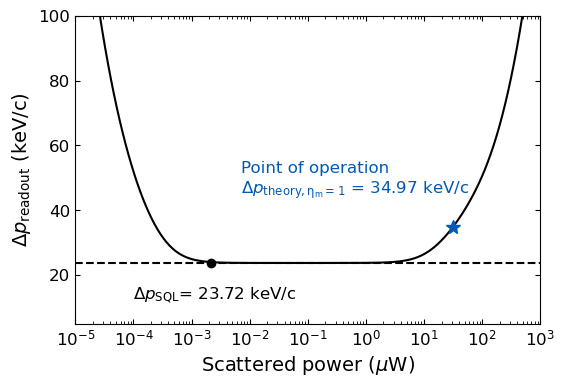

In [74]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(power_scale * p_sca / 1e-6, dp_ideal, 'k')
ax.plot(p_sca/1e-6, dp_kev_theory_ideal, '*', color='#005AB5', markersize=10)
ax.plot(power_scale[np.argmin(dp_ideal)], dp_ideal[np.argmin(dp_ideal)], 'ko')

# ax.vlines(x=p_sca/1e-6, ymin=0, ymax=150, color='#005AB5')
# ax.vlines(x=power_scale[np.argmin(dp_ideal)], ymin=0, ymax=150, color='k')
ax.hlines(y=dp_sql, xmin=1e-5, xmax=1e3, color='k', linestyles='--')

ax.set_xscale('log')

ax.set_xlim(1e-5, 1e3)
ax.set_ylim(5, 100)

ax.text(1e-4, 12.5, fr'$\Delta p_\mathrm{{SQL}}$= {dp_sql:.2f} keV/c', fontsize=12)
ax.text(7e-3, 45, 'Point of operation\n'+rf'$\Delta p_\mathrm{{theory, \eta_m = 1}}$ = {dp_kev_theory_ideal:.2f} keV/c', color='#005AB5', fontsize=12)
# ax.annotate(
#     '', 
#     xytext=(2, 45), 
#     xy=(13, 30),
#     arrowprops=dict(arrowstyle='->', color='#005AB5', lw=1.5)
# )


ax.set_xlabel(r'Scattered power ($\mu$W)')
ax.set_ylabel(r'$\Delta p_\mathrm{readout}$ (keV/c)')

# plt.savefig('../paper_plots/sql_power_scaling.pdf', dpi=600)

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_8399/2741706128.py:9: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$z$ ($z_{\mathrm{zpf}}$)')
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_8399/2741706128.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('$p_z$ ($p_{\mathrm{zpf}}$)')


Text(0, 0.5, '$p_z$ ($p_{\\mathrm{zpf}}$)')

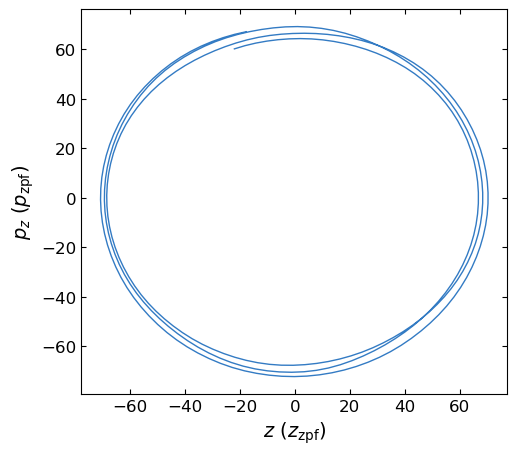

In [26]:
zz = zz_bp * c_mv                  # position [m]
pp = m * np.gradient(zz) / (2e-7)  # momentum; [kg] * [m/s]

fig, ax = plt.subplots(1, 1, figsize=(5.5, 5))

lb, ub = 2000, 2300
ax.plot(zz[lb:ub]/zpf, pp[lb:ub]/pzpf, '-', alpha=0.8, linewidth=1, color='#005AB5')

ax.set_xlabel('$z$ ($z_{\mathrm{zpf}}$)')
ax.set_ylabel('$p_z$ ($p_{\mathrm{zpf}}$)')